# Debugging `latent_sde` on PushT — how does behavior change with the latent strategy `z`?

This notebook loads a trained **latent_sde** checkpoint and probes how the policy's behavior depends
on the per-chunk latent strategy `z`, entirely in the **live `gym_pusht` simulator** (closed-loop).

**Idea.** At a chosen frame we freeze the image conditioning `h`, sample several `z`, and roll out
`horizon` steps in the sim holding `(h, z)` fixed (the full chunk `z` was trained to govern; at deploy the
policy executes only the first `n_action_steps` of that plan before refreshing `h`/`z`). Comparing the
rollouts shows how much `z` steers behavior.

**Two `z` sources.**
- `prior`  — `p(z|h)`: the deployable path; samples fan out across strategies.
- `posterior` — `q(z|traj)`: infeasible at deploy (needs the future). We compute it offline from a
  *reference chunk* rolled from the same frame; samples concentrate near the `z` that explains that future.
  The posterior traj matches training: `cat([state, action])` over the chunk (latent_sde always conditions on the action).

We force **deterministic** inference (drift-only: `x_d = x + mu*dt`, no SDE diffusion noise), so all
branch differences are due to `z`.

**Setup.** Use the `lerobot` conda env. Point `CHECKPOINT_PATH` at a checkpoint dir
(`.../checkpoints/<step>/pretrained_model`).

In [149]:
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym
import gym_pusht  # noqa: F401  (registers gym_pusht/PushT-v0)

from lerobot.configs import PreTrainedConfig
from lerobot.policies.factory import make_policy, make_pre_post_processors
from lerobot.datasets import LeRobotDatasetMetadata
from lerobot.envs.utils import preprocess_observation
from lerobot.utils.constants import OBS_STATE, OBS_IMAGE, OBS_IMAGES, ACTION

REPO_ROOT = "/home/v-hihwang/lerobot"
CHECKPOINT_PATH = f"{REPO_ROOT}/outputs/train/dp_crop84/checkpoints/100000/pretrained_model"  # EDIT ME
REPO_ID = "lerobot/pusht"
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

cfg = PreTrainedConfig.from_pretrained(CHECKPOINT_PATH)
cfg.pretrained_path = CHECKPOINT_PATH
cfg.device = device

meta = LeRobotDatasetMetadata(REPO_ID)
policy = make_policy(cfg, ds_meta=meta).eval()
model = getattr(policy, "model", None)   # latent_sde -> LatentSDEModel; diffusion -> None (its net is policy.diffusion, unused here)
# H = the TRAINING prediction / rollout chunk length (== cfg.horizon; both latent_sde and diffusion have
# it). latent_sde unrolls the SDE H steps (teacher-forced) and its posterior encodes an H-length chunk. n_act =
# cfg.n_action_steps = actions EXECUTED per replan at deploy. Sections 2-3 (z-viz) are latent_sde-only;
# section 4 (deploy spread) is policy-agnostic and also supports diffusion checkpoints.
n_obs, H, n_act = cfg.n_obs_steps, cfg.horizon, cfg.n_action_steps
preprocessor, postprocessor = make_pre_post_processors(policy_cfg=cfg, pretrained_path=CHECKPOINT_PATH)

is_latent_sde = model is not None and hasattr(model, "use_latent_z")   # False for a diffusion checkpoint
if is_latent_sde:
    # latent_sde is a stochastic SDE; force drift-only (deterministic) inference so every branch's
    # only source of variation is z (matches the reference debug intent). Set False to see SDE noise.
    policy.config.deterministic_inference = True
print("checkpoint:", CHECKPOINT_PATH, "| policy:", policy.name)
if is_latent_sde:
    print(f"use_latent_z={model.use_latent_z} z_dim={model.z_dim} z_uses_h={model.z_uses_h} "
          f"use_vq={model.use_vq} use_pe={cfg.use_pe} "
          f"sde_dt={cfg.sde_dt}")
print(f"n_obs={n_obs} horizon={H} n_action_steps={n_act}")

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 53601.33it/s]


Loading weights from local directory
checkpoint: /home/v-hihwang/lerobot/outputs/train/dp_crop84/checkpoints/100000/pretrained_model | policy: diffusion
n_obs=2 horizon=16 n_action_steps=8


In [150]:
# --- normalization helpers (state/action are MIN-MAX in this policy) -------------------------------
def _stat(key, name):
    return torch.as_tensor(meta.stats[key][name], dtype=torch.float32, device=device).reshape(-1)

S_MIN, S_MAX = _stat(OBS_STATE, "min"), _stat(OBS_STATE, "max")   # agent-position (state) range
A_MIN, A_MAX = _stat(ACTION, "min"),   _stat(ACTION, "max")       # action range

def norm_mm(x, lo, hi):   return 2.0 * (x - lo) / (hi - lo).clamp_min(1e-8) - 1.0
def unnorm_mm(x, lo, hi): return (x + 1.0) / 2.0 * (hi - lo) + lo

def norm_state_np(xy):
    # (...,2) numpy world position -> normalized tensor on device
    return norm_mm(torch.as_tensor(np.asarray(xy), dtype=torch.float32, device=device), S_MIN, S_MAX)

print("state  min/max:", S_MIN.tolist(), S_MAX.tolist())
print("action min/max:", A_MIN.tolist(), A_MAX.tolist())

state  min/max: [13.45642375946045, 32.93829345703125] [496.14617919921875, 510.9578857421875]
action min/max: [12.0, 25.0] [511.0, 511.0]


In [151]:
# --- live PushT env: obs at TRAINING resolution (96); render high-res for display only -------------
def make_pusht(obs_hw=96, vis_hw=384, max_steps=300):
    return gym.make(
        "gym_pusht/PushT-v0", obs_type="pixels_agent_pos", render_mode="rgb_array",
        observation_width=obs_hw, observation_height=obs_hw,
        visualization_width=vis_hw, visualization_height=vis_hw, max_episode_steps=max_steps,
    )

_img_ft = cfg.input_features.get(OBS_IMAGE)
_img_hw = _img_ft.shape[-1] if _img_ft is not None else 96   # match checkpoint's training image size
env = make_pusht(obs_hw=_img_hw, vis_hw=384)
env.reset()   # instantiate the block so we can read its center-of-gravity offset (fixed T geometry)
# CoG offset (local, ~[0,45]): the pymunk block rotates about its CoG, so specifying a block *center*
# and deriving origin = center - BLOCK_COG makes the T rotate in place about that center (see section 2).
BLOCK_COG = np.array(env.unwrapped.block.center_of_gravity, dtype=np.float64)
print("obs image size:", _img_hw, "| action space:", env.action_space, "| block CoG offset:", BLOCK_COG)

obs image size: 96 | action space: Box(0.0, 512.0, (2,), float32) | block CoG offset: [ 0. 45.]


In [152]:
# --- build a branch from a USER-SPECIFIED PushT state (T-block pose + peg/agent position) ----------
@torch.no_grad()
def branch_from_state(env, state5, seed=0):
    # state5 = [peg_x, peg_y, block_x, block_y, block_angle]  (world px in [0,512]; angle rad in [0,2*pi)).
    # Reset the sim to it, then snapshot the branch with NO motion history: one select_action call fills
    # the obs queues with the static start frame repeated n_obs times (the same warmup the policy uses at
    # episode reset).
    policy.reset()
    obs, info = env.reset(seed=seed, options={"reset_to_state": [float(v) for v in state5]})
    policy.select_action(preprocessor(preprocess_observation(obs)))     # populate queues, no env step
    imgs = torch.stack(list(policy._queues[OBS_IMAGES]), dim=1)          # (1, n_obs, 1, C, H, W)
    h = model.encode_observations({OBS_IMAGES: imgs})
    state_deque = [s.clone() for s in policy._queues[OBS_STATE]]
    # Return the ORIGINAL requested state5 (NOT info["block_pose"]): block.angle rotates the T about its
    # center of gravity, so the post-reset block origin differs from block_xy when angle != 0. Feeding
    # block_pose back into reset_to_state would RE-apply that rotation, so rollout_sim must reset to the
    # SAME state5 the branch used to stay consistent with the frozen h.
    return {"h": h, "state_deque": state_deque,
            "state5": np.asarray(state5, dtype=np.float64),
            "render": env.render(), "info": info}

In [153]:
# --- roll out n_steps in the REAL sim, holding (h, z) fixed (opt: per-rollout START-obs jitter) ---
@torch.no_grad()
def encode_h_from_obs(obs):
    # Encode the image conditioning h from a SINGLE env obs, warming the image window with n_obs copies
    # of this frame (matches branch_from_state / the policy's episode-reset warmup). Pure: does NOT mutate
    # policy queues. Lets PEG_NOISE_STD perturb the IMAGE observation h, not just the state feedback.
    b = preprocessor(preprocess_observation(obs))
    img1 = torch.stack([b[k] for k in cfg.image_features], dim=-4)   # (1, cam, C, H, W) — one frame
    imgs = img1.unsqueeze(1).repeat_interleave(n_obs, dim=1)         # (1, n_obs, cam, C, H, W)
    return model.encode_observations({OBS_IMAGES: imgs})

@torch.no_grad()
def rollout_sim(env, state5, state_deque, h, z, n_steps, peg_noise_std=None):
    # peg_noise_std (world px) jitters the START observation for THIS rollout; None -> read PEG_NOISE_STD.
    if peg_noise_std is None:
        peg_noise_std = globals().get("PEG_NOISE_STD", 0.0)
    state5 = np.asarray(state5, dtype=np.float64).copy()
    if peg_noise_std > 0:
        state5[:2] = state5[:2] + np.random.randn(2) * peg_noise_std          # jitter START peg (agent)
    obs, info = env.reset(options={"reset_to_state": [float(v) for v in state5]})
    if peg_noise_std > 0:
        # FULL start-observation perturbation: re-derive BOTH the image conditioning h AND the state
        # window from the jittered frame (repeat n_obs -> zero initial velocity), so the policy sees a
        # CONSISTENT jittered observation (image + state), not just a state-feedback disturbance. The
        # committed strategy z stays from the base frame.
        h = encode_h_from_obs(obs)
        w0 = norm_state_np(obs["agent_pos"]).reshape(1, -1)
        win = deque([w0.clone() for _ in range(n_obs)], maxlen=n_obs)
    else:
        win = deque([s.clone().to(device) for s in state_deque], maxlen=n_obs)  # real branch history
    agent_xy = [np.asarray(obs["agent_pos"], dtype=np.float64)]
    block = [np.asarray(info["block_pose"], dtype=np.float64)]
    frames = [env.render()]
    anchor_norm, action_norm, success = [], [], False
    for t in range(n_steps):
        x_aug = torch.stack(list(win), dim=1).reshape(1, -1)        # (1, n_obs*state_dim)
        a_norm = model.step(x_aug, h, z, step_idx=t)                # (1, action_dim); step_idx = PE index (use_pe)
        anchor_norm.append(win[-1].clone()); action_norm.append(a_norm.clone())
        a_env = unnorm_mm(a_norm, A_MIN, A_MAX).to("cpu").numpy().reshape(-1)
        obs, r, term, trunc, info = env.step(a_env)
        agent_xy.append(np.asarray(obs["agent_pos"], dtype=np.float64))
        block.append(np.asarray(info["block_pose"], dtype=np.float64))
        frames.append(env.render())
        win.append(norm_state_np(obs["agent_pos"]).reshape(1, -1))  # closed-loop: feed MEASURED state
        success = success or bool(info.get("is_success", False))
    return {"agent_xy": np.array(agent_xy), "block_pose": np.array(block), "frames": frames,
            "success": success,
            "anchor_norm": torch.cat(anchor_norm, 0) if anchor_norm else None,
            "action_norm": torch.cat(action_norm, 0) if action_norm else None}

In [154]:
# --- z sampling (prior / posterior; Gaussian or FSQ/VQ) ------------------------------------------
@torch.no_grad()
def sample_z(h, mode, K, traj=None, valid=None):
    if not model.use_latent_z:
        return None
    if mode == "prior":
        return model.sample_z_from_prior(h.expand(K, -1).contiguous(), deterministic=False)  # (K, z_dim)
    if mode == "posterior":
        args = (traj, valid, h) if model.z_uses_h else (traj, valid)
        if model.use_vq:
            z_e = model.posterior(*args)
            z_q, _ = model.vq(z_e.unsqueeze(1))
            return z_q.squeeze(1).expand(K, -1).contiguous()   # VQ posterior deterministic -> K identical
        mu_q, sigma_q = model.posterior(*args)                 # (1, z_dim) each
        return mu_q + sigma_q * torch.randn(K, model.z_dim, device=h.device)
    raise ValueError(mode)

@torch.no_grad()
def collect_ref_chunk(env, branch, n_steps=None):
    # One reference chunk (prior z) -> per-chunk posterior traj, matching the TRAINING posterior input:
    # cat([state, action]) over an H(=horizon)-length chunk.
    # peg_noise_std=0.0: the posterior conditions on the CLEAN base future (jitter only the final rollouts).
    n_steps = n_steps or H
    z0 = sample_z(branch["h"], "prior", 1)
    out = rollout_sim(env, branch["state5"], branch["state_deque"], branch["h"], z0, n_steps, peg_noise_std=0.0)
    # latent_sde's posterior always encodes cat([state, action]) (input_dim = state_dim + action_dim).
    traj = torch.cat([out["anchor_norm"], out["action_norm"]], dim=-1).unsqueeze(0)  # (1, H, state+action)
    valid = torch.ones(1, traj.shape[1], dtype=torch.bool, device=device)
    return traj, valid

In [155]:
# --- orchestrator: given a branch, sample K z's, roll out each -----------------------------------
import diptest
from scipy.spatial.distance import pdist

def compare_z_eval(env, branch, K=6, mode="prior", n_steps=None):
    n_steps = n_steps or H
    traj = valid = None
    if mode == "posterior":
        traj, valid = collect_ref_chunk(env, branch, n_steps=H)
    z = sample_z(branch["h"], mode, K, traj=traj, valid=valid)
    outs = [rollout_sim(env, branch["state5"], branch["state_deque"], branch["h"], z[k:k+1], n_steps)
            for k in range(K)]
    return branch, z, outs

# --- trajectory-level multimodality: aligned-RMSE + Hartigan dip test ----------------------------
def outs_to_plans(outs):
    """Stack K rollouts' agent paths into (K, T, 2), truncated to the shortest (time-aligned)."""
    T = min(len(o["agent_xy"]) for o in outs)
    return np.stack([np.asarray(o["agent_xy"])[:T] for o in outs])

def traj_multimodality(plans):
    """plans: (K, T, 2) time-aligned trajectories. Compare whole curves (not endpoints):
    aligned-RMSE pairwise distance (= Euclidean in the flattened 2T-D curve space) -> leading
    PCA coordinate PC1 (axis of max spread) -> Hartigan's dip test. Returns the p-value
    (H0: unimodal); multimodal = p < 0.05."""
    K, T, _ = plans.shape
    X  = plans.reshape(K, -1).astype(np.float64)             # (K, 2T) flattened curves
    Xc = X - X.mean(0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)        # PCA of the flattened curves (Euclidean = aligned-RMSE)
    pc1 = Xc @ Vt[0]                                         # (K,) leading coordinate (spread axis)
    pc2 = Xc @ Vt[1] if len(S) > 1 else np.zeros(K)
    dip, p = diptest.diptest(np.ascontiguousarray(pc1))
    rmse = pdist(X) / np.sqrt(T)                             # full-curve aligned-RMSE (px), for context
    return dict(pc1=pc1, pc2=pc2, dip=float(dip), pval=float(p),
                mean_rmse=float(rmse.mean()), max_rmse=float(rmse.max()), multimodal=bool(p < 0.05))

In [156]:
# --- plotting ------------------------------------------------------------------------------------
FLIP_Y = False  # PushT render maps world (x,y) directly to pixels under extent=[0,512,512,0]. Toggle if mirrored.

def _ty(y):
    return (512.0 - np.asarray(y)) if FLIP_Y else np.asarray(y)

def plot_eval(branch, outs, mode, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(branch["render"], extent=[0, 512, 512, 0])
    cmap, K = plt.get_cmap("turbo"), len(outs)
    for k, o in enumerate(outs):
        c = cmap(k / max(K - 1, 1)); xy = o["agent_xy"]
        ax.plot(xy[:, 0], _ty(xy[:, 1]), "-", color=c, lw=1.8, alpha=0.9)
        ax.plot(xy[-1, 0], _ty(xy[-1, 1]), "o", color=c, ms=6, mec="k", mew=0.5)
        bp = o["block_pose"][-1]
        ax.plot(bp[0], _ty(bp[1]), "s", color=c, ms=7, mec="k", mew=0.6, alpha=0.8)
    s0 = branch["state5"][:2]
    ax.plot(s0[0], _ty(s0[1]), "*", color="white", ms=16, mec="k", mew=1.0)
    ax.set_xlim(0, 512); ax.set_ylim(512, 0); ax.set_xticks([]); ax.set_yticks([])
    st = traj_multimodality(outs_to_plans(outs))   # trajectory-level: aligned-RMSE + dip test
    ax.set_title(f"{mode}  K={K}  RMSE={st['mean_rmse']:.1f}px  dip p={st['pval']:.3f}"
                 f"{'  MULTIMODAL' if st['multimodal'] else ''}  succ={sum(o['success'] for o in outs)}/{K}")
    return ax

def plot_prior_vs_posterior(env, branch, K=6):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.3))
    for ax, mode in zip(axes, ["prior", "posterior"]):
        _, z, outs = compare_z_eval(env, branch, K=K, mode=mode)
        plot_eval(branch, outs, mode, ax=ax)
    fig.suptitle("z-behavior at custom start   (star=peg, circle=final agent, square=final block)")
    fig.tight_layout(); plt.show()

def final_frame_grid(outs, title=""):
    K = len(outs); cols = min(K, 6); rows = int(np.ceil(K / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.4 * rows), squeeze=False)
    cmap = plt.get_cmap("turbo")
    for k in range(rows * cols):
        ax = axes[k // cols][k % cols]; ax.axis("off")
        if k < K:
            ax.imshow(outs[k]["frames"][-1])
            ax.set_title(f"z[{k}]{' OK' if outs[k]['success'] else ''}",
                         color=cmap(k / max(K - 1, 1)), fontsize=9)
    fig.suptitle(title); fig.tight_layout(); plt.show()

## 1. Sanity check — does the checkpoint drive PushT?

Run one full closed-loop episode with the standard processors and watch the video before interpreting
z-effects. (A moderate ~30k-step checkpoint typically makes clear progress toward the goal.)

We force **deterministic** inference (drift-only: `x_d = x + mu*dt`, no SDE diffusion noise), so the
rollout is fully determined by `(h, z)` and the start state — one episode characterizes the checkpoint.

In [157]:
from pathlib import Path
from lerobot.utils.io_utils import write_video
from IPython.display import Video, display

@torch.no_grad()
def run_episode(env, seed=0, max_steps=300):
    policy.reset()
    obs, info = env.reset(seed=seed)
    frames, success, ret = [env.render()], False, 0.0
    for _ in range(max_steps):
        o = preprocessor(preprocess_observation(obs))
        a = postprocessor(policy.select_action(o)).to("cpu").numpy().reshape(-1)
        obs, r, term, trunc, info = env.step(a)
        frames.append(env.render()); ret += float(r)
        success = success or bool(info.get("is_success", False))
        if term or trunc:
            break
    return frames, success, ret

# Inference is always deterministic (drift-only), so one episode fully characterizes the checkpoint.
frames, success, ret = run_episode(env, seed=0)
print(f"episode: steps={len(frames) - 1}  success={success}  return={ret:.1f}")
out_mp4 = f"{REPO_ROOT}/outputs/latent_sde_debug_sanity.mp4"
Path(out_mp4).parent.mkdir(parents=True, exist_ok=True)
write_video(out_mp4, [np.asarray(f, dtype=np.uint8) for f in frames], fps=10)
display(Video(out_mp4, embed=True, width=384))

episode: steps=91  success=True  return=40.6


## 2. 1-chunk rollout from a CUSTOM Push-T state

Set the initial **T-block** center + orientation and the **peg** (agent) position, reset the sim to
exactly that state, then compare **K single-chunk rollouts** — how far do the sampled strategies fan out?
Coordinates are world pixels in `[0, 512]` (origin top-left, y-down); `BLOCK_ANGLE` is radians in `[0, 2*pi)`.
`BLOCK_CENTER` is the T's rotation center (its CoG); internally `origin = center - BLOCK_COG` so the T spins
in place. **Two paths — run the one matching your checkpoint:**

- **§2a `latent_sde`** — branches come from the latent `z` (**prior** vs **posterior**), holding `(h, z)`
  fixed over the horizon plan.
- **§2b `diffusion`** — branches come from the **denoising noise**: K full-`horizon` action chunks sampled
  from the same frozen frame, each executed **open-loop**.

Set **`PEG_NOISE_STD > 0`** (world px) to additionally jitter the **start peg per rollout** — a disturbance
test on top of the strategy branches. The jitter perturbs the **full start observation**: in §2a both the
image conditioning `h` **and** the state window are re-derived from the jittered frame (the policy sees a
consistent jittered image + state); only the committed `z` (§2a) / chunk (§2b) stays from the base frame.
Edit the values below, re-run the preview to check placement, then run §2a or §2b (each self-guards on the
loaded checkpoint type, so running both is harmless).

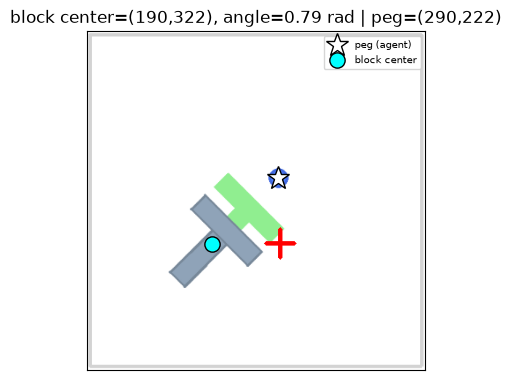

In [158]:
import math
# ---- your custom Push-T start state (edit these, then re-run) ----------------------------------
PEG_XY        = (290.0, 222.0)  # peg = agent / pusher position            (world px, [0,512])
BLOCK_CENTER  = (190.0, 322.0)  # T-block rotation center (~visual centre)  (world px, [0,512])
BLOCK_ANGLE   = math.pi / 4     # T-block orientation                      (radians, [0, 2*pi))
PEG_NOISE_STD = 0             # >0: per-rollout Gaussian jitter (world px) on the START peg (try ~10-30)
# The T rotates about its center of gravity, so derive the pymunk body origin that puts the CoG at
# BLOCK_CENTER -> the block spins IN PLACE about BLOCK_CENTER for any angle.
block_origin = np.array(BLOCK_CENTER, dtype=np.float64) - BLOCK_COG
state5 = [PEG_XY[0], PEG_XY[1], block_origin[0], block_origin[1], BLOCK_ANGLE]

# preview (policy-agnostic): reset to state5 and render; star = peg, cyan circle = block center.
_obs, _info = env.reset(seed=0, options={"reset_to_state": [float(v) for v in state5]})
ax_, ay_ = _info["pos_agent"]
plt.figure(figsize=(4.4, 4.4)); plt.imshow(env.render(), extent=[0, 512, 512, 0])
plt.plot(ax_, ay_, "*", color="white", ms=17, mec="k", mew=1.0, label="peg (agent)")
plt.plot(BLOCK_CENTER[0], BLOCK_CENTER[1], "o", color="cyan", ms=11, mec="k", mew=1.0, label="block center")
plt.title(f"block center=({BLOCK_CENTER[0]:.0f},{BLOCK_CENTER[1]:.0f}), angle={BLOCK_ANGLE:.2f} rad | peg=({ax_:.0f},{ay_:.0f})")
plt.xlim(0, 512); plt.ylim(512, 0); plt.xticks([]); plt.yticks([])
plt.legend(loc="upper right", fontsize=7); plt.show()

### 2a. `latent_sde` path — `z` branches (prior / posterior)

Latent-SDE only: freeze `(h, z)` and roll the horizon plan per sampled `z`. `prior` = `p(z|h)` (deployable);
`posterior` = `q(z|traj)` (needs a realized future, infeasible at deploy). Skipped for a diffusion checkpoint.

In [159]:
# §2a latent_sde — prior z branches (skipped for a diffusion checkpoint)
if is_latent_sde:
    branch = branch_from_state(env, state5)
    _, z, outs = compare_z_eval(env, branch, K=6, mode="prior")
    plot_eval(branch, outs, "prior"); plt.show()
    final_frame_grid(outs, title="prior z  @ custom start")
else:
    print("§2a is the latent_sde path — skip for a diffusion checkpoint (use §2b).")

§2a is the latent_sde path — skip for a diffusion checkpoint (use §2b).


In [160]:
# §2a latent_sde — posterior z branches (uses `branch` from the prior cell)
if is_latent_sde:
    _, z, outs = compare_z_eval(env, branch, K=6, mode="posterior")
    plot_eval(branch, outs, "posterior"); plt.show()
    final_frame_grid(outs, title="posterior z  @ custom start")

In [161]:
# §2a latent_sde — prior vs posterior side by side (same custom start, K rollouts per side)
if is_latent_sde:
    plot_prior_vs_posterior(env, branch, K=6)

### 2b. `diffusion` path — action-chunk branches (denoising noise)

Diffusion only: sample K full-`horizon` action chunks from the frozen frame (varying only the denoising
noise), execute each **open-loop** in the sim. This is DP's analog of §2a's `z`-fan-out — its multimodality
comes from the sampler, not a latent (no posterior). Skipped for a latent_sde checkpoint.

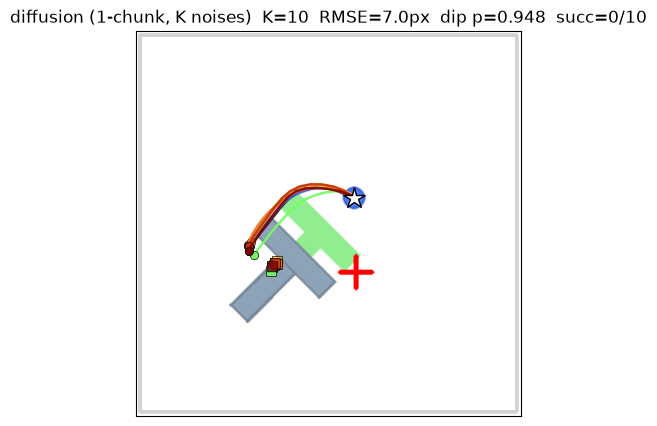

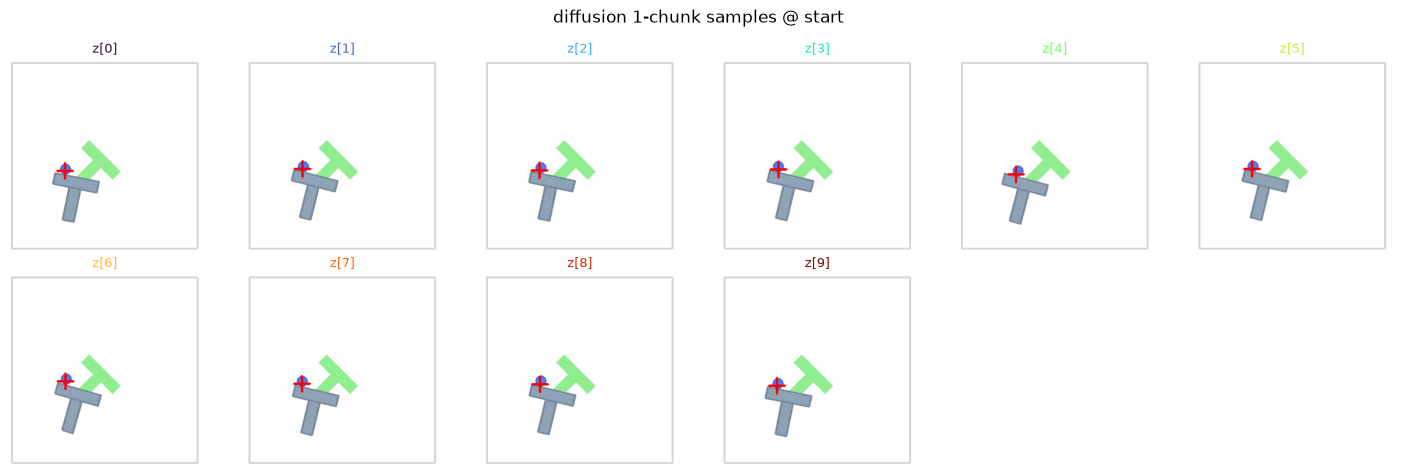

In [162]:
# --- §2b diffusion: K full-horizon action chunks from the frozen frame, each rolled OPEN-LOOP -------
@torch.no_grad()
def dp_branch(env, state5, seed=0):
    # Warm up the obs queues from the frozen frame (populate_queues fills n_obs copies), then snapshot
    # the stacked (normalized) obs batch DP conditions on: {state:(1,n_obs,d), images:(1,n_obs,cam,C,H,W)}.
    policy.reset()
    obs, info = env.reset(seed=seed, options={"reset_to_state": [float(v) for v in state5]})
    policy.select_action(preprocessor(preprocess_observation(obs)))          # warm up queues (no env step)
    batch = {k: torch.stack(list(policy._queues[k]), dim=1) for k in (OBS_STATE, OBS_IMAGES)}
    return {"batch": batch, "state5": np.asarray(state5, np.float64), "render": env.render(), "info": info}

@torch.no_grad()
def dp_sample_chunks(branch, K, seed0=0):
    # K full-horizon action chunks from the SAME frozen obs, varying only the denoising noise seed.
    dp = policy.diffusion
    gc = dp._prepare_global_conditioning(branch["batch"])                    # (1, global_cond_dim)
    chunks = [dp.conditional_sample(1, global_cond=gc,
                                    generator=torch.Generator(device=device).manual_seed(seed0 + k))
              for k in range(K)]
    return torch.cat(chunks, 0)                                              # (K, horizon, action_dim), normalized

@torch.no_grad()
def rollout_chunk_openloop(env, state5, chunk_norm, peg_noise_std=None):
    # Execute a predicted chunk OPEN-LOOP (no re-planning) from state5. DP's chunk overlaps the past by
    # n_obs-1 steps, so the FUTURE actions start at index n_obs-1 (mirrors DiffusionModel.generate_actions).
    # peg_noise_std (world px) jitters the START peg only; the chunk (absolute targets) is unchanged.
    if peg_noise_std is None:
        peg_noise_std = globals().get("PEG_NOISE_STD", 0.0)
    state5 = np.asarray(state5, dtype=np.float64).copy()
    if peg_noise_std > 0:
        state5[:2] = state5[:2] + np.random.randn(2) * peg_noise_std
    obs, info = env.reset(options={"reset_to_state": [float(v) for v in state5]})
    agent_xy = [np.asarray(obs["agent_pos"], np.float64)]; block = [np.asarray(info["block_pose"], np.float64)]
    frames = [env.render()]; success = False
    for a_norm in chunk_norm[cfg.n_obs_steps - 1:]:
        a_env = unnorm_mm(a_norm, A_MIN, A_MAX).to("cpu").numpy().reshape(-1)
        obs, r, term, trunc, info = env.step(a_env)
        agent_xy.append(np.asarray(obs["agent_pos"], np.float64)); block.append(np.asarray(info["block_pose"], np.float64))
        frames.append(env.render()); success = success or bool(info.get("is_success", False))
        if term or trunc:
            break
    return {"agent_xy": np.array(agent_xy), "block_pose": np.array(block), "frames": frames, "success": success}

def compare_diffusion(env, state5, K=6, seed0=0):
    branch = dp_branch(env, state5)
    chunks = dp_sample_chunks(branch, K, seed0=seed0)
    outs = [rollout_chunk_openloop(env, state5, chunks[k]) for k in range(K)]
    plot_eval(branch, outs, "diffusion (1-chunk, K noises)"); plt.show()
    final_frame_grid(outs, title="diffusion 1-chunk samples @ start")
    return branch, chunks, outs

if policy.name == "diffusion":
    _ = compare_diffusion(env, state5, K=10)
else:
    print("§2b is the diffusion path — skip for a latent_sde checkpoint (use §2a).")

## 3. Verification & how to read the results

- **"branches fan out" ⇔ the policy commits to distinct strategies** from the same start (large `spread`).
  If they overlap, the sampled degree of freedom isn't steering behavior.
- `latent_sde` (§2a): the prior `z` explores strategies; the **posterior** `z` (conditioned on a realized
  future) should cluster **tighter**. NB the training `z_usage_gap` uses the *posterior* z — the
  deploy-relevant question is whether the **prior** branches fan out.
- `diffusion` (§2b): the K chunks come from the **denoising noise** — this is DP's multimodality (e.g.
  left/right around the T). There is no posterior analog.
- **Determinism**: `latent_sde` inference is forced drift-only (setup cell) (`x_d = x + mu*dt`), so §2a spread is purely `z`.
  `diffusion` is stochastic by construction, so §2b spread is the denoising noise.
- If overlays look vertically mirrored, flip the `FLIP_Y` constant in the plotting cell.

**horizon vs n_action_steps.** §2a holds `(h, z)` fixed and rolls the full **`horizon`** plan (PE index
`0..horizon-1`); §2b executes a full-`horizon` predicted chunk **open-loop**. At *deployment* both execute
only the first **`n_action_steps`** of the plan before re-planning — see §4 for the deploy-consistent,
re-planning view.

**Checkpoint compatibility.** `latent_sde` (Gaussian / FSQ-VQ, `use_pe`) uses
§1 / §2a / §3 / §4; `diffusion` uses §1 / §2b / §3 / §4 (skip §2a). Loading a checkpoint requires this repo
at the same-or-newer commit that defines its config fields — on a `DecodingError` update the code and
**restart the kernel** so the new `lerobot` is imported.

In [163]:
# shape + sanity asserts (branch on checkpoint type)
if is_latent_sde:
    b = branch_from_state(env, [256.0, 400.0, 256.0, 256.0, 0.0])
    assert b["h"].shape == (1, model.h_dim), b["h"].shape
    zt = sample_z(b["h"], "prior", 5); assert zt.shape == (5, model.z_dim), zt.shape
    xw = torch.stack(list(b["state_deque"]), dim=1).reshape(1, -1)
    assert xw.shape == (1, n_obs * model.state_dim), xw.shape
    a = model.step(xw, b["h"], zt[:1]); assert a.shape == (1, model.action_dim), a.shape
    _, _, o = compare_z_eval(env, b, K=6, mode="prior")
    st = traj_multimodality(outs_to_plans(o))
    print(f"latent_sde prior: RMSE {st['mean_rmse']:.1f}px  dip p={st['pval']:.3f} | shape checks passed")
else:  # diffusion: K full-horizon chunks from a frozen frame (defs come from §2b)
    br = dp_branch(env, [256.0, 400.0, 256.0, 256.0, 0.0])
    ch = dp_sample_chunks(br, 5)
    assert ch.shape[1:] == (cfg.horizon, cfg.action_feature.shape[0]), ch.shape
    o = [rollout_chunk_openloop(env, br["state5"], ch[k]) for k in range(len(ch))]
    st = traj_multimodality(outs_to_plans(o))
    print(f"diffusion chunk: RMSE {st['mean_rmse']:.1f}px  dip p={st['pval']:.3f} | chunk shape {tuple(ch.shape)} checks passed")

diffusion chunk: RMSE 2.9px  dip p=0.345 | chunk shape (5, 16, 2) checks passed


## 4. Multimodal-state scan — how often does the policy branch across states?

Sweep `SCAN_N` random start states; at each, draw `SCAN_K` stochastic single-chunk plans — **denoising noise**
for a `diffusion` checkpoint, **prior `z`** for a `latent_sde` checkpoint — and measure multimodality at the
**trajectory level**: compare whole curves by **aligned-RMSE** (Euclidean in the flattened `2*T`-D space),
take the leading PCA coordinate `PC1`, and run **Hartigan's dip test**. A state is flagged multimodal when
the dip **p-value < 0.05** (rejects unimodality). Policy-agnostic; mirrors `dp_check.ipynb` (the official-DP
notebook), so numbers are directly comparable.

In [164]:
# --- §4 multimodal-state scan: K stochastic plans per state (metric defined in the orchestrator cell) ---
@torch.no_grad()
def plans_at_state(state5, K=16, seed=0):
    """K stochastic single-chunk plans at state5, as (K, T, 2) world-px trajectories.
    diffusion : K predicted horizon chunks (vary only denoising noise), absolute agent targets.
    latent_sde: realized agent paths under K prior-z rollouts (deterministic SDE drift -> z is the only knob)."""
    if is_latent_sde:
        br = branch_from_state(env, state5)
        z  = sample_z(br["h"], "prior", K)                                              # (K, z_dim)
        outs = [rollout_sim(env, br["state5"], br["state_deque"], br["h"], z[k:k+1], H) for k in range(K)]
        T = min(len(o["agent_xy"]) for o in outs)
        return np.stack([o["agent_xy"][:T] for o in outs]), br["render"]                # (K, T, 2) world px
    br = dp_branch(env, state5); dp = policy.diffusion
    gc = dp._prepare_global_conditioning(br["batch"]).expand(K, -1).contiguous()        # (K, global_cond_dim)
    chunks = dp.conditional_sample(K, global_cond=gc,
                                   generator=torch.Generator(device=device).manual_seed(seed))  # (K,H,adim)
    return unnorm_mm(chunks, A_MIN, A_MAX).cpu().numpy(), br["render"]                   # (K, H, 2) world px

# multimodality metric = traj_multimodality (aligned-RMSE + dip test), defined in the orchestrator cell above.

diffusion: 120 random states -> dip-multimodal (p<0.05) 3/120 (2.5%) | median dip p 0.731
top-5 most-multimodal states (smallest dip p; plug state5 into the §2 cell to view a branch):
  p=0.0020  dip=0.1338  mean_rmse= 56.7px  state5=[203.0, 351.0, 328.0, 300.0, 4.53]
  p=0.0030  dip=0.1312  mean_rmse= 39.2px  state5=[377.0, 195.0, 143.0, 199.0, 3.63]
  p=0.0405  dip=0.1080  mean_rmse=  4.8px  state5=[169.0, 447.0, 140.0, 214.0, 0.41]
  p=0.0517  dip=0.1049  mean_rmse=  5.9px  state5=[210.0, 367.0, 288.0, 197.0, 6.03]
  p=0.0771  dip=0.1008  mean_rmse= 24.2px  state5=[305.0, 281.0, 308.0, 129.0, 4.12]


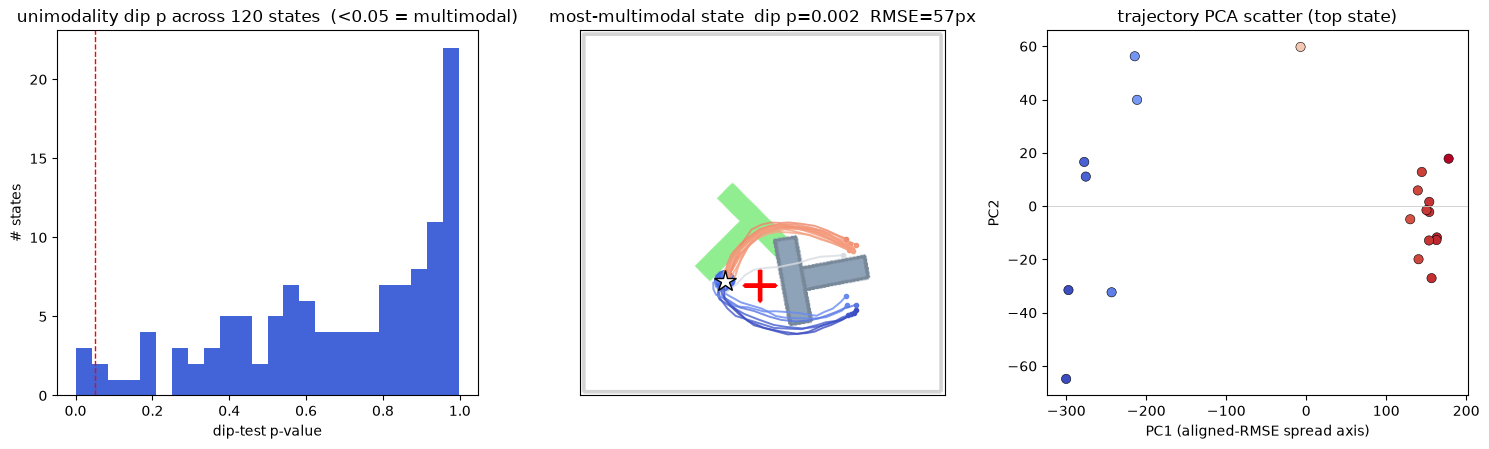

In [165]:
SCAN_N, SCAN_K, ALPHA = 120, 20, 0.05   # states to sweep, stochastic samples per state, dip significance

rng = np.random.RandomState(100000)   # same seed family as DP eval / dp_check
rows = []
for i in range(SCAN_N):
    s = np.array([rng.randint(60, 452), rng.randint(60, 452),
                  rng.randint(110, 402), rng.randint(110, 402), rng.uniform(0, 2 * np.pi)])
    plans, render = plans_at_state(s, K=SCAN_K)
    st = traj_multimodality(plans)
    rows.append({"state5": s, "plans": plans, "render": render, **st})

pvals = np.array([r["pval"] for r in rows]); hits = int((pvals < ALPHA).sum())
print(f"{policy.name}: {SCAN_N} random states -> dip-multimodal (p<{ALPHA}) {hits}/{SCAN_N} "
      f"({100 * hits / SCAN_N:.1f}%) | median dip p {np.median(pvals):.3f}")
rows.sort(key=lambda r: r["pval"])   # smallest p = strongest multimodality
print("top-5 most-multimodal states (smallest dip p; plug state5 into the §2 cell to view a branch):")
for r in rows[:5]:
    print(f"  p={r['pval']:.4f}  dip={r['dip']:.4f}  mean_rmse={r['mean_rmse']:5.1f}px  "
          f"state5={np.round(r['state5'], 2).tolist()}")

top = rows[0]; pc1 = top["pc1"]; sc = np.max(np.abs(pc1)) + 1e-9
cmap = plt.get_cmap("coolwarm"); colf = lambda v: cmap(0.5 + 0.5 * v / sc)   # color by PC1 (spread axis)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
ax[0].hist(pvals, bins=24, color="#4363d8"); ax[0].axvline(ALPHA, color="r", ls="--", lw=1)
ax[0].set_xlabel("dip-test p-value"); ax[0].set_ylabel("# states")
ax[0].set_title(f"unimodality dip p across {SCAN_N} states  (<{ALPHA} = multimodal)")
ax[1].imshow(top["render"], extent=[0, 512, 512, 0])
for k in range(len(top["plans"])):
    c = top["plans"][k]; ax[1].plot(c[:, 0], _ty(c[:, 1]), "-", color=colf(pc1[k]), lw=1.4, alpha=0.8)
    ax[1].plot(c[-1, 0], _ty(c[-1, 1]), ".", color=colf(pc1[k]), ms=6)
ax[1].plot(top["state5"][0], _ty(top["state5"][1]), "*", color="white", ms=16, mec="k", mew=1.0)
ax[1].set_xlim(0, 512); ax[1].set_ylim(512, 0); ax[1].set_xticks([]); ax[1].set_yticks([])
ax[1].set_title(f"most-multimodal state  dip p={top['pval']:.3f}  RMSE={top['mean_rmse']:.0f}px")
ax[2].scatter(top["pc1"], top["pc2"], c=top["pc1"], cmap="coolwarm", s=45, edgecolor="k", lw=0.4)
ax[2].axhline(0, color="#ccc", lw=0.6); ax[2].set_xlabel("PC1 (aligned-RMSE spread axis)")
ax[2].set_ylabel("PC2"); ax[2].set_title("trajectory PCA scatter (top state)")
plt.tight_layout(); plt.show()